In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch

In [2]:
selected_points_path = '/home/toddc/research/Online-Batch-Selection/selected_points/MNIST_Noise/'
noisy_indicies_path = '/home/toddc/research/Online-Batch-Selection/labels/'
noise_percent = '0.8'
method = 'DivBS'
dataset = 'MNIST'
network = ''

In [3]:
def load_data(selected_points_path, noisy_indices_path, noise_percent):
    """
    Returns how many times noisy and non noisy points were selected

    Args:
        selected_points_path (str): Path to the folder containing containing the selected points
        noisy_indices_path (str): Path to the folder containing the noisy labels
        noise_percent (str): Percentage of noisy points

    Returns:
        num_epochs (int): Number of epochs for the given run
        num_data (int): Size of input dataset
        selected_points (ndarray): Ndarray of shape (num_epochs, num_data) indicating which points were selected in which epochs
        noisy_mask (ndarray): Mask of noisy points. True means index is a noisy point
        num_selected_noisy (ndarray): Number of times each noisy point (index) was selected
        num_selected_non_noisy (ndarray): Number of times each non noisy point (index) was selected
    """

    # Loads selected points 
    selected_points = np.load(selected_points_path + f'{{"bsel":"DivBS","seed":1,"model":"LeNet","opt":"adamw","bs":320,"ratio":0.1,"lr":0.001,"wd":0.01,"noise_percent":{noise_percent}}}.npy')
    num_epochs, num_data = selected_points.shape

    # Creates array of how many times each point was selected
    num_selected = selected_points.sum(axis=0)

    # Loads array of noisy indicies. This array is not sorted
    noisy_indices = torch.load(
        noisy_indices_path + f"MNIST_noise_{noise_percent}p.p",
        map_location="cpu"
    )['noisy_indices']

    # Creates a mask of noisy indicides. True = Noisy. False = Non-noisy
    noisy_mask = np.zeros(len(num_selected), dtype=bool)
    noisy_mask[noisy_indices] = True

    num_selected_noisy = num_selected[noisy_mask]
    num_selected_non_noisy = num_selected[~noisy_mask]

    return num_epochs, num_data, selected_points, noisy_mask, num_selected_noisy, num_selected_non_noisy

In [4]:
num_epochs, num_data, selected_points, noisy_mask, num_selected_noisy, num_selected_non_noisy = load_data(selected_points_path, noisy_indicies_path, noise_percent)



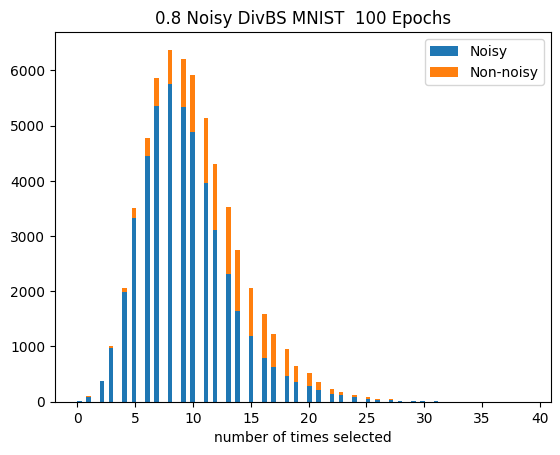

In [5]:
# Plots histogram that stacks the non-noisy points on top of the noisy points
plt.hist([num_selected_noisy, num_selected_non_noisy], bins=num_epochs, stacked=True, label=["Noisy", "Non-noisy"])
plt.legend()

plt.xlabel('number of times selected')
plt.title(f'{noise_percent} Noisy {method} {dataset} {network} {num_epochs} Epochs')
plt.show()

In [ ]:
def last_selection(num_epochs, selected_points, noisy_mask, num_data):
    last_selection_noisy = np.zeros(noisy_mask.sum())
    last_selection_non_noisy = np.zeros(num_data - noisy_mask.sum())
    selected_noisy = selected_points[:, noisy_mask]
    selected_non_noisy = selected_points[:, ~noisy_mask]
    for i in range(num_epochs)[::-1]:
        curr_epoch_noisy = selected_noisy[i, :]
        curr_epoch_non_noisy = selected_non_noisy[i, :]
        last_noisy_mask = (curr_epoch_noisy == 1) & (last_selection_noisy == 0)
        last_non_noisy_mask = (curr_epoch_non_noisy == 1) & (last_selection_non_noisy == 0)
        last_selection_noisy[last_noisy_mask] += i
        last_selection_non_noisy[last_non_noisy_mask] += i
    return last_selection_noisy, last_selection_non_noisy


In [155]:
last_selection_noisy, last_selection_non_noisy = last_selection(num_epochs, selected_points, noisy_mask, num_data)

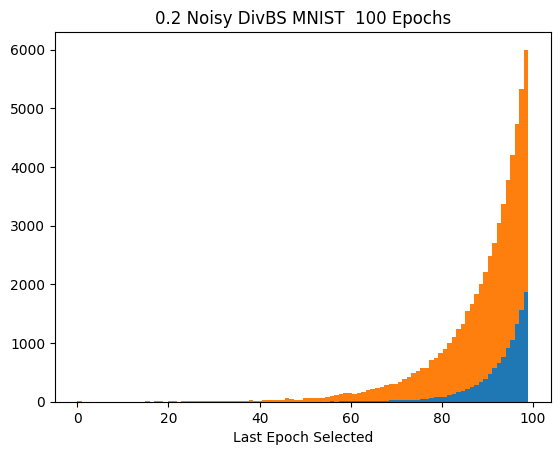

In [156]:
plt.hist([last_selection_noisy, last_selection_non_noisy], bins=num_epochs, stacked=True, label=["Noisy", "Non-noisy"])

plt.xlabel('Last Epoch Selected')
plt.title(f'{noise_percent} Noisy {method} {dataset} {network} {num_epochs} Epochs')
plt.show()

/tmp/ipykernel_16864/2138181597.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  num_fig.show()
/tmp/ipykernel_16864/2138181597.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  last_fig.show()


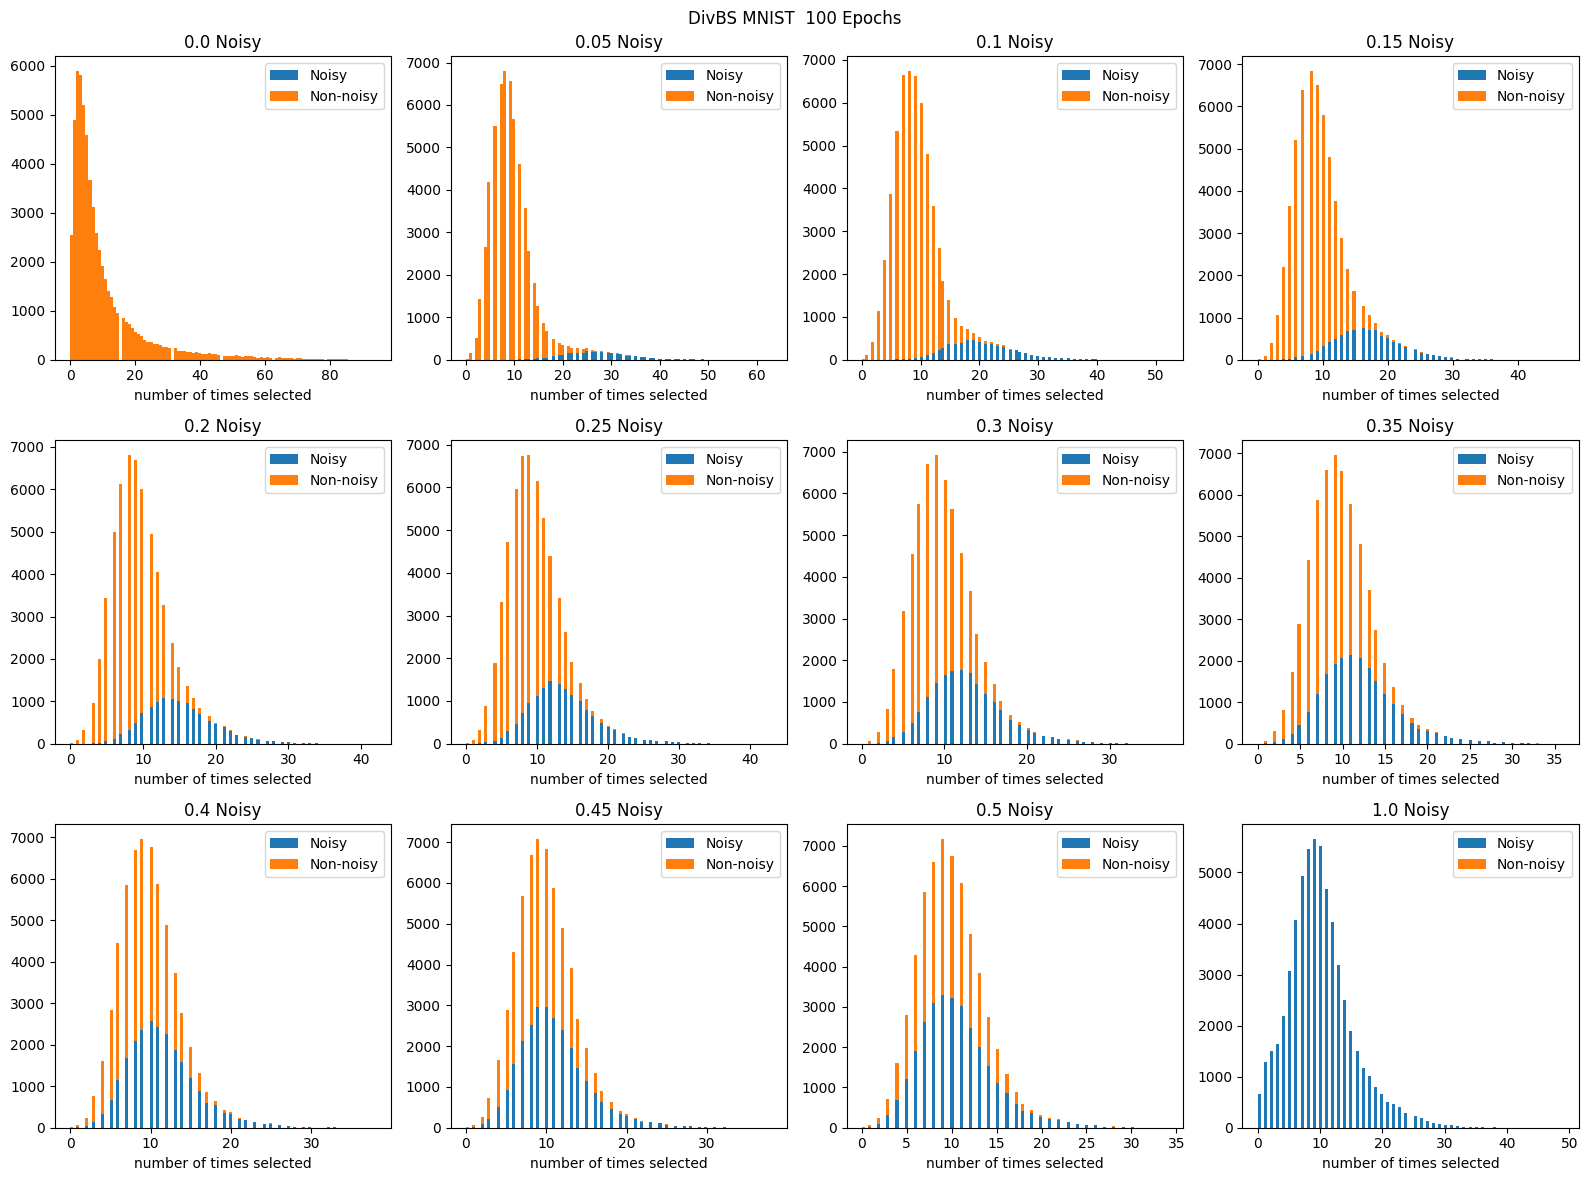

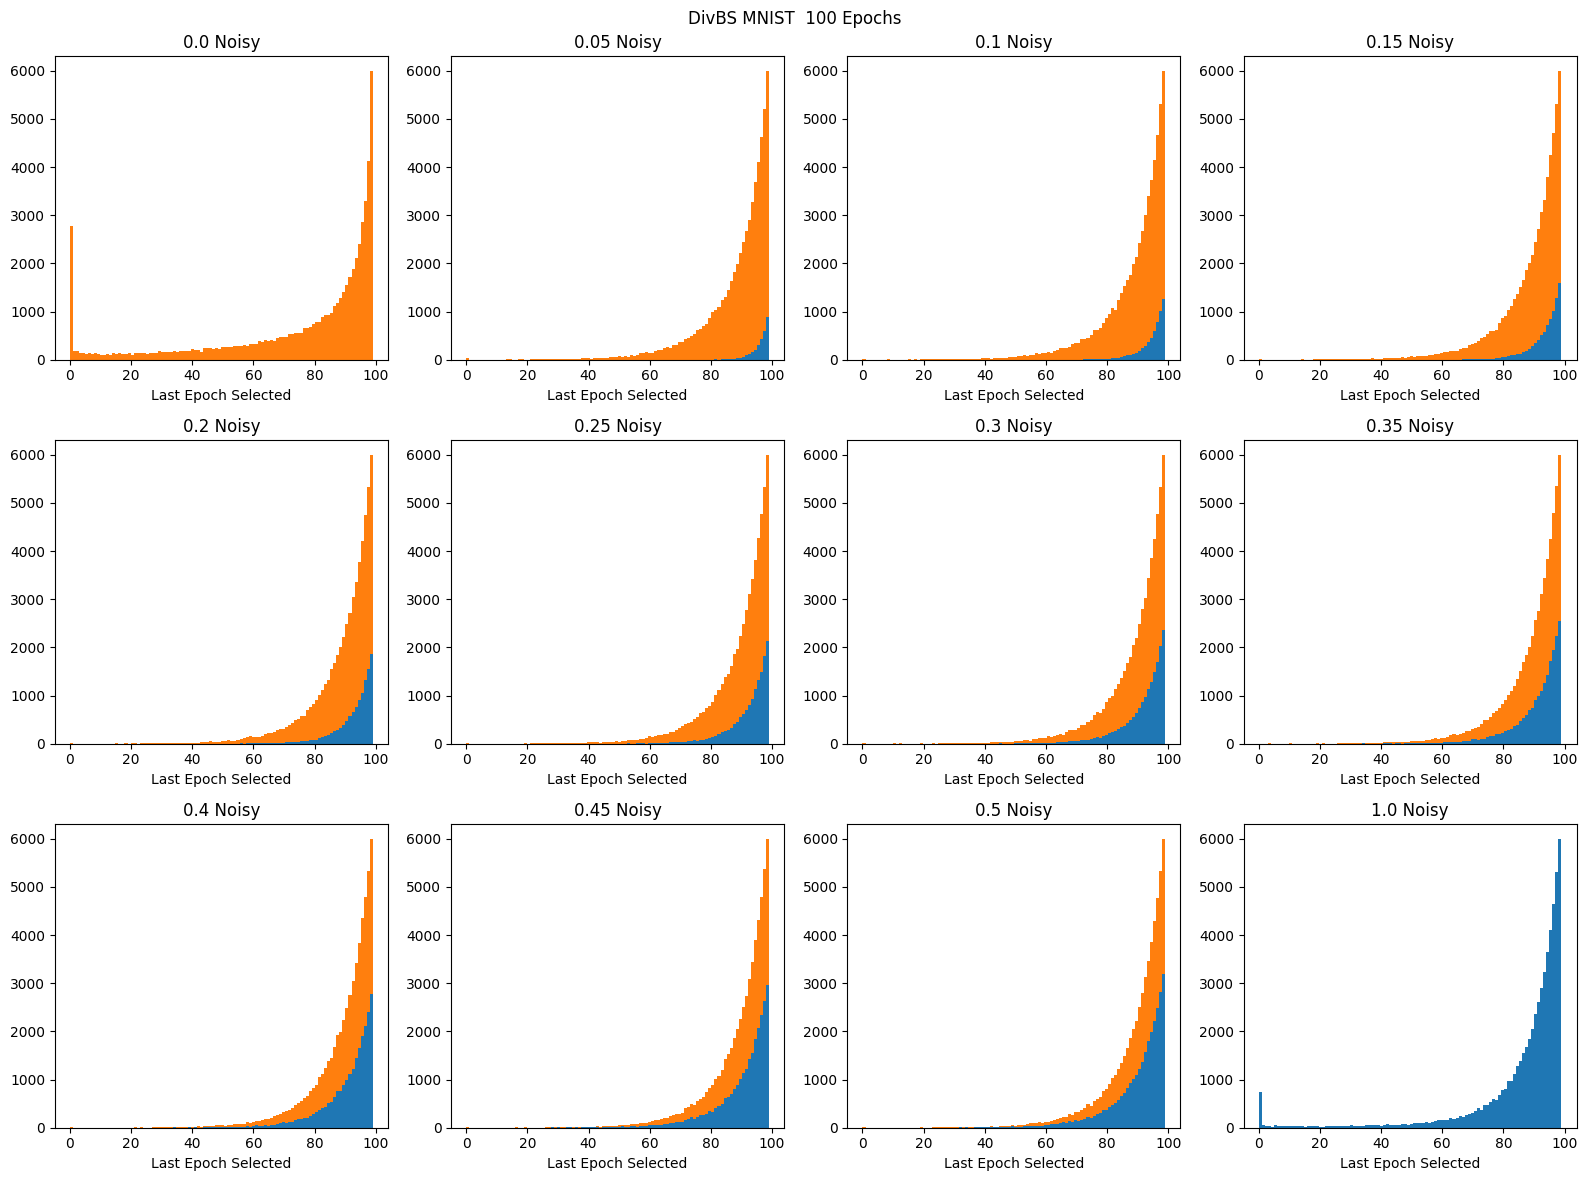

In [172]:
percents = iter(['0.0', '0.05', '0.1', '0.15', '0.2', '0.25', '0.3', '0.35', '0.4', '0.45', '0.5', '1.0'])
num_fig, num_axes = plt.subplots(3, 4, figsize=(16, 12))
last_fig, last_axes = plt.subplots(3, 4, figsize=(16, 12))
for i in range(3):
    for j in range(4):
        if i == 2 and j == 4:
            pass
        else:
            num_ax = num_axes[i, j]
            last_ax = last_axes[i, j]

            percent = next(percents)
            num_epochs, num_data, selected_points, noisy_mask, num_selected_noisy, num_selected_non_noisy = load_data(selected_points_path, noisy_indicies_path, percent)

            num_ax.hist([num_selected_noisy, num_selected_non_noisy], bins=num_epochs, stacked=True, label=["Noisy", "Non-noisy"])
            num_ax.legend()

            num_ax.set_xlabel('number of times selected')
            num_ax.set_title(f'{percent} Noisy')

            last_selection_noisy, last_selection_non_noisy = last_selection(num_epochs, selected_points, noisy_mask, num_data)

            last_ax.hist([last_selection_noisy, last_selection_non_noisy], bins=num_epochs, stacked=True, label=["Noisy", "Non-noisy"])

            last_ax.set_xlabel('Last Epoch Selected')
            last_ax.set_title(f'{percent} Noisy')

num_fig.suptitle(f'{method} {dataset} {network} {num_epochs} Epochs')
num_fig.tight_layout()
num_fig.show()

last_fig.suptitle(f'{method} {dataset} {network} {num_epochs} Epochs')
last_fig.tight_layout()
last_fig.show()
        
        